# Ayan's `XGBDT SHAP` Values Analysis

## Purpose: 

{TODO}

In [1]:
%load_ext autoreload 
%autoreload 2
    
import importlib
    
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"
from IPython.display import Image
from IPython.display import display

import pandas as pd
pd.set_option('display.max_rows', 1000000)
pd.set_option('display.max_columns', 1000000)
pd.set_option('display.max_colwidth', 10000000)


import polars as pl 
_=pl.Config.set_tbl_cols(100000)
_=pl.Config.set_tbl_rows(100000)
_=pl.Config.set_tbl_width_chars(10000)

import matplotlib.pyplot as plt 
import seaborn as sns 

AyanXgbdtAnalyzer = getattr(
    importlib.import_module("1_Ayan_XGBDT_Analyzer"), 
    "AyanXgbdtAnalyzer"
)

CellLineCompareTool = getattr(
    importlib.import_module("1_Ayan_XGBDT_Analyzer"), 
    "CellLineCompareTool"
)



## Literals

In [2]:
cell_lines = ["K562", "HepG2"]
best_performing_distance_threshold=100

## Load Analyzer Class (per Cell Line)

In [3]:
analyzers = {}

for cell_line in cell_lines:
    
    analyzers[cell_line] = AyanXgbdtAnalyzer(
        cell_line = cell_line, 
        distance_threshold = best_performing_distance_threshold
    )

2024-10-10 19:05:39.458 | INFO     | 1_Ayan_XGBDT_Analyzer:load_rbp_ppi:64 - FROM CACHE: RBP PPI info loaded
2024-10-10 19:05:39.459 | INFO     | 1_Ayan_XGBDT_Analyzer:load_rbp_ppi:64 - FROM CACHE: RBP PPI info loaded


# **CTRL-Only Binding Analyses**

## Load `CTRL`-only `binding data` to understand **UNIVARIATE** associations between `RBPs`/features and `PSI`

In [ ]:
for cell_line in analyzers:
    analyzers[cell_line].load_ctrl_only_binding_data()

#### Duplication issue!!!

The issue is that when looking at binding, etc. there is duplication. 
For example, the skipping exon could be an upstream or downstream exon for the neighboring exon's SE event. 

Hence, let's see how many times each "main exon" is either an upstream or downstream exon. 

In [ ]:
for cell_line in analyzers: 

    cell_line 
    
    counts = analyzers[cell_line].plot_upstream_and_downstream_exon_duplication()

    counts["Counts"].describe()

#### `Chi-Square Test` **FOR EACH** feature where the categories are "Binding Present/Absent" and "PSI threshold group"

In [ ]:
for cell_line in analyzers: 

    analyzers[cell_line].run_parallel_chi_square_tests().head()

In [ ]:
analyzers[cell_line].feature_chi_square_contingency_tables["AQR_center_right"]

In [ ]:
for cell_line in analyzers: 
    analyzers[cell_line].plot_chi_square_contingency_tables().head()

In [ ]:
for cell_line in analyzers:
    
    analyzers[cell_line].plot_feature_chi_square_statistics(column="Statistic")

## Is there any relationship between chromosome and PSI values?

In [ ]:
for cell_line in analyzers: 
    analyzers[cell_line].compare_chromosome_vs_psi()

# **GLOBAL `SHAP` Analyses** 

## Load `SHAP` Datasets

In [4]:
for cell_line in analyzers: 
    analyzers[cell_line].load_SHAP_data()

2024-10-10 19:05:55.943 | INFO     | 1_Ayan_XGBDT_Analyzer:load_SHAP_data:533 - FROM CACHE: K562 100 SHAP data loaded
Could not memory_map compressed IPC file, defaulting to normal read. Toggle off 'memory_map' to silence this warning.
2024-10-10 19:06:13.776 | SUCCESS  | 1_Ayan_XGBDT_Analyzer:load_SHAP_data:546 - K562 100 SHAP dataframe loaded. Shape: (2252043, 1671)


AARS_5_left,AATF_5_left,ABCF1_5_left,ADAT1_5_left,AGGF1_5_left,AKAP1_5_left,AKAP8L_5_left,APEX1_5_left,APOBEC3C_5_left,AQR_5_left,BUD13_5_left,CPEB4_5_left,CPSF6_5_left,CSTF2T_5_left,DDX1_5_left,DDX21_5_left,DDX24_5_left,DDX3X_5_left,DDX42_5_left,DDX43_5_left,DDX47_5_left,DDX51_5_left,DDX52_5_left,DDX55_5_left,DDX6_5_left,DGCR8_5_left,DHX30_5_left,DROSHA_5_left,EEF2_5_left,EFTUD2_5_left,EIF3G_5_left,EIF4E_5_left,EIF4G2_5_left,ELAC2_5_left,ELAVL1_5_left,EWSR1_5_left,EXOSC10_5_left,EXOSC5_5_left,FAM120A_5_left,FASTKD2_5_left,FMR1_5_left,FTO_5_left,FUS_5_left,FXR1_5_left,FXR2_5_left,GARS_5_left,GEMIN5_5_left,GNL3_5_left,GPKOW_5_left,GRWD1_5_left,GTF2F1_5_left,HLTF_5_left,HNRNPA1_5_left,HNRNPC_5_left,HNRNPK_5_left,HNRNPL_5_left,HNRNPM_5_left,HNRNPU_5_left,HNRNPUL1_5_left,IGF2BP1_5_left,IGF2BP2_5_left,ILF3_5_left,KHDRBS1_5_left,KHSRP_5_left,LARP4_5_left,LARP7_5_left,LIN28B_5_left,LSM11_5_left,MATR3_5_left,MBNL1_5_left,METAP2_5_left,METTL1_5_left,MORC2_5_left,MTPAP_5_left,NCBP2_5_left,NIPBL_5_left,NOLC1_5_left,NONO_5_left,NPM1_5_left,NSUN2_5_left,PABPC4_5_left,PCBP1_5_left,PHF6_5_left,PPIL4_5_left,PRPF8_5_left,PTBP1_5_left,PUM1_5_left,PUM2_5_left,PUS1_5_left,QKI_5_left,RBFOX2_5_left,RBM15_5_left,RBM22_5_left,RNF187_5_left,RPS10_5_left,RPS11_5_left,RPS3_5_left,RPS6_5_left,RYBP_5_left,SAFB_5_left,SAFB2_5_left,SBDS_5_left,SDAD1_5_left,SERBP1_5_left,SF3B1_5_left,SF3B4_5_left,SLBP_5_left,SLTM_5_left,SMNDC1_5_left,SND1_5_left,SRSF1_5_left,SRSF7_5_left,SRSF9_5_left,SSB_5_left,SUPV3L1_5_left,TAF15_5_left,TARDBP_5_left,TBRG4_5_left,TIA1_5_left,TRA2A_5_left,TROVE2_5_left,U2AF1_5_left,U2AF2_5_left,UCHL5_5_left,UPF1_5_left,UTP18_5_left,UTP3_5_left,WDR3_5_left,WDR43_5_left,WRN_5_left,XRCC6_5_left,XRN2_5_left,YBX3_5_left,YWHAG_5_left,ZC3H11A_5_left,ZC3H8_5_left,ZNF622_5_left,ZNF800_5_left,ZRANB2_5_left,AARS_5_right,AATF_5_right,ABCF1_5_right,ADAT1_5_right,AGGF1_5_right,AKAP1_5_right,AKAP8L_5_right,APEX1_5_right,APOBEC3C_5_right,AQR_5_right,BUD13_5_right,CPEB4_5_right,CPSF6_5_right,CSTF2T_5_right,DDX1_5_right,DDX21_5_right,DDX24_5_right,DDX3X_5_right,DDX42_5_right,DDX43_5_right,DDX47_5_right,DDX51_5_right,DDX52_5_right,DDX55_5_right,DDX6_5_right,DGCR8_5_right,DHX30_5_right,DROSHA_5_right,EEF2_5_right,EFTUD2_5_right,EIF3G_5_right,EIF4E_5_right,EIF4G2_5_right,ELAC2_5_right,ELAVL1_5_right,EWSR1_5_right,EXOSC10_5_right,EXOSC5_5_right,FAM120A_5_right,FASTKD2_5_right,FMR1_5_right,FTO_5_right,FUS_5_right,FXR1_5_right,FXR2_5_right,GARS_5_right,GEMIN5_5_right,GNL3_5_right,GPKOW_5_right,GRWD1_5_right,GTF2F1_5_right,HLTF_5_right,HNRNPA1_5_right,HNRNPC_5_right,HNRNPK_5_right,HNRNPL_5_right,HNRNPM_5_right,HNRNPU_5_right,HNRNPUL1_5_right,IGF2BP1_5_right,IGF2BP2_5_right,ILF3_5_right,KHDRBS1_5_right,KHSRP_5_right,LARP4_5_right,LARP7_5_right,LIN28B_5_right,LSM11_5_right,MATR3_5_right,MBNL1_5_right,METAP2_5_right,METTL1_5_right,MORC2_5_right,MTPAP_5_right,NCBP2_5_right,NIPBL_5_right,NOLC1_5_right,NONO_5_right,NPM1_5_right,NSUN2_5_right,PABPC4_5_right,PCBP1_5_right,PHF6_5_right,PPIL4_5_right,PRPF8_5_right,PTBP1_5_right,PUM1_5_right,PUM2_5_right,PUS1_5_right,QKI_5_right,RBFOX2_5_right,RBM15_5_right,RBM22_5_right,RNF187_5_right,RPS10_5_right,RPS11_5_right,RPS3_5_right,RPS6_5_right,RYBP_5_right,SAFB_5_right,SAFB2_5_right,SBDS_5_right,SDAD1_5_right,SERBP1_5_right,SF3B1_5_right,SF3B4_5_right,SLBP_5_right,SLTM_5_right,SMNDC1_5_right,SND1_5_right,SRSF1_5_right,SRSF7_5_right,SRSF9_5_right,SSB_5_right,SUPV3L1_5_right,TAF15_5_right,TARDBP_5_right,TBRG4_5_right,TIA1_5_right,TRA2A_5_right,TROVE2_5_right,U2AF1_5_right,U2AF2_5_right,UCHL5_5_right,UPF1_5_right,UTP18_5_right,UTP3_5_right,WDR3_5_right,WDR43_5_right,WRN_5_right,XRCC6_5_right,XRN2_5_right,YBX3_5_right,YWHAG_5_right,ZC3H11A_5_right,ZC3H8_5_right,ZNF622_5_right,ZNF800_5_right,ZRANB2_5_right,AARS_center_left,AATF_center_left,ABCF1_center_left,ADAT1_center_left,AGGF1_center_left,AKAP1_center_left,AKAP8L_center_left,APEX1_center_left,APOBEC3C_center_left,AQR_center_left,BUD13_center_left,CPEB4_center_left,CPSF6_center_left

2024-10-10 19:06:13.858 | INFO     | 1_Ayan_XGBDT_Analyzer:load_SHAP_data:533 - FROM CACHE: HepG2 100 SHAP data loaded
Could not memory_map compressed IPC file, defaulting to normal read. Toggle off 'memory_map' to silence this warning.
2024-10-10 19:06:27.200 | SUCCESS  | 1_Ayan_XGBDT_Analyzer:load_SHAP_data:546 - HepG2 100 SHAP dataframe loaded. Shape: (2083000, 1263)


AGGF1_5_left,AKAP1_5_left,AQR_5_left,BCCIP_5_left,BCLAF1_5_left,BUD13_5_left,CDC40_5_left,CSTF2_5_left,CSTF2T_5_left,DDX3X_5_left,DDX52_5_left,DDX55_5_left,DDX59_5_left,DDX6_5_left,DGCR8_5_left,DHX30_5_left,DKC1_5_left,DROSHA_5_left,EFTUD2_5_left,EIF3D_5_left,EIF3H_5_left,EXOSC5_5_left,FAM120A_5_left,FASTKD2_5_left,FKBP4_5_left,FTO_5_left,FUBP3_5_left,FUS_5_left,FXR2_5_left,G3BP1_5_left,GRSF1_5_left,GRWD1_5_left,GTF2F1_5_left,HLTF_5_left,HNRNPA1_5_left,HNRNPC_5_left,HNRNPK_5_left,HNRNPL_5_left,HNRNPM_5_left,HNRNPU_5_left,HNRNPUL1_5_left,IGF2BP1_5_left,IGF2BP3_5_left,ILF3_5_left,KHSRP_5_left,LARP4_5_left,LARP7_5_left,LIN28B_5_left,LSM11_5_left,MATR3_5_left,NCBP2_5_left,NIP7_5_left,NKRF_5_left,NOL12_5_left,NOLC1_5_left,NSUN2_5_left,PABPN1_5_left,PCBP1_5_left,PCBP2_5_left,POLR2G_5_left,PPIG_5_left,PRPF4_5_left,PRPF8_5_left,PTBP1_5_left,QKI_5_left,RBFOX2_5_left,RBM15_5_left,RBM22_5_left,RBM5_5_left,RPS3_5_left,SAFB_5_left,SDAD1_5_left,SF3A3_5_left,SF3B4_5_left,SFPQ_5_left,SLTM_5_left,SMNDC1_5_left,SND1_5_left,SRSF1_5_left,SRSF7_5_left,SRSF9_5_left,SSB_5_left,STAU2_5_left,SUB1_5_left,SUGP2_5_left,SUPV3L1_5_left,TAF15_5_left,TARDBP_5_left,TBRG4_5_left,TIA1_5_left,TIAL1_5_left,TRA2A_5_left,TROVE2_5_left,U2AF1_5_left,U2AF2_5_left,UCHL5_5_left,UPF1_5_left,UTP18_5_left,WDR43_5_left,XPO5_5_left,XRCC6_5_left,XRN2_5_left,YBX3_5_left,ZC3H11A_5_left,ZNF800_5_left,AGGF1_5_right,AKAP1_5_right,AQR_5_right,BCCIP_5_right,BCLAF1_5_right,BUD13_5_right,CDC40_5_right,CSTF2_5_right,CSTF2T_5_right,DDX3X_5_right,DDX52_5_right,DDX55_5_right,DDX59_5_right,DDX6_5_right,DGCR8_5_right,DHX30_5_right,DKC1_5_right,DROSHA_5_right,EFTUD2_5_right,EIF3D_5_right,EIF3H_5_right,EXOSC5_5_right,FAM120A_5_right,FASTKD2_5_right,FKBP4_5_right,FTO_5_right,FUBP3_5_right,FUS_5_right,FXR2_5_right,G3BP1_5_right,GRSF1_5_right,GRWD1_5_right,GTF2F1_5_right,HLTF_5_right,HNRNPA1_5_right,HNRNPC_5_right,HNRNPK_5_right,HNRNPL_5_right,HNRNPM_5_right,HNRNPU_5_right,HNRNPUL1_5_right,IGF2BP1_5_right,IGF2BP3_5_right,ILF3_5_right,KHSRP_5_right,LARP4_5_right,LARP7_5_right,LIN28B_5_right,LSM11_5_right,MATR3_5_right,NCBP2_5_right,NIP7_5_right,NKRF_5_right,NOL12_5_right,NOLC1_5_right,NSUN2_5_right,PABPN1_5_right,PCBP1_5_right,PCBP2_5_right,POLR2G_5_right,PPIG_5_right,PRPF4_5_right,PRPF8_5_right,PTBP1_5_right,QKI_5_right,RBFOX2_5_right,RBM15_5_right,RBM22_5_right,RBM5_5_right,RPS3_5_right,SAFB_5_right,SDAD1_5_right,SF3A3_5_right,SF3B4_5_right,SFPQ_5_right,SLTM_5_right,SMNDC1_5_right,SND1_5_right,SRSF1_5_right,SRSF7_5_right,SRSF9_5_right,SSB_5_right,STAU2_5_right,SUB1_5_right,SUGP2_5_right,SUPV3L1_5_right,TAF15_5_right,TARDBP_5_right,TBRG4_5_right,TIA1_5_right,TIAL1_5_right,TRA2A_5_right,TROVE2_5_right,U2AF1_5_right,U2AF2_5_right,UCHL5_5_right,UPF1_5_right,UTP18_5_right,WDR43_5_right,XPO5_5_right,XRCC6_5_right,XRN2_5_right,YBX3_5_right,ZC3H11A_5_right,ZNF800_5_right,AGGF1_center_left,AKAP1_center_left,AQR_center_left,BCCIP_center_left,BCLAF1_center_left,BUD13_center_left,CDC40_center_left,CSTF2_center_left,CSTF2T_center_left,DDX3X_center_left,DDX52_center_left,DDX55_center_left,DDX59_center_left,DDX6_center_left,DGCR8_center_left,DHX30_center_left,DKC1_center_left,DROSHA_center_left,EFTUD2_center_left,EIF3D_center_left,EIF3H_center_left,EXOSC5_center_left,FAM120A_center_left,FASTKD2_center_left,FKBP4_center_left,FTO_center_left,FUBP3_center_left,FUS_center_left,FXR2_center_left,G3BP1_center_left,GRSF1_center_left,GRWD1_center_left,GTF2F1_center_left,HLTF_center_left,HNRNPA1_center_left,HNRNPC_center_left,HNRNPK_center_left,HNRNPL_center_left,HNRNPM_center_left,HNRNPU_center_left,HNRNPUL1_center_left,IGF2BP1_center_left,IGF2BP3_center_left,ILF3_center_left,KHSRP_center_left,LARP4_center_left,LARP7_center_left,LIN28B_center_left,LSM11_center_left,MATR3_center_left,NCBP2_center_left,NIP7_center_left,NKRF_center_left,NOL12_center_left,NOLC1_center_left,NSUN2_center_left,PABPN1_center_left,PCBP1_center_left,PCBP2_center_left,POLR2G_center_left,PPIG_center_left,PRPF4_center_left,PRPF8_center_left,PTBP1_

## How similar are the `predicted` vs `actual` `PSI` values for this model?


In [ ]:
for cell_line in analyzers: 
    analyzers[cell_line].predicted_vs_actual_PSI_model()

## What are the `Global SHAP` values like for our features and how does that correlate with: 
* Total amount of binding?
* Positional preferences of RBPs?


In [ ]:
for cell_line in analyzers: 
    analyzers[cell_line].plot_global_SHAP_vs_binding_plots()

## What are the above plots like if we subset to different PSI thresholds?

In [ ]:
for cell_line in analyzers: 
    analyzers[cell_line].plot_partition_global_SHAP_vs_binding_plots()

In [ ]:
for cell_line in analyzers: 
    analyzers[cell_line].plot_partition_percent_events_bound()
    analyzers[cell_line].plot_partition_global_SHAP()

## Which features have Global SHAPs that monotonically increase or decrease with `PSI` bin?

In [ ]:
for cell_line in analyzers: 
    analyzers[cell_line].plot_global_SHAP_partition_monotonicity()

## How does the rank of a feature's `Global SHAP` correspond to the rank of that same feature's `Chi-Square Statistic`?

In [ ]:
for cell_line in analyzers: 
    analyzers[cell_line].plot_rank_global_SHAP_vs_rank_chi_square()

## For each feature, how does `Chi Square`, `ANOVA`, `Kruskal Wallis`, and `Global SHAP` compare?

In [ ]:
for cell_line in analyzers: 
    analyzers[cell_line].plot_kruskal_anova_chi_SHAP().head()

# **LOCAL `SHAP` Analyses** 

## Does the distribution of local `SHAP` values significantly differ between the 3 `PSI` threshold groups?

NOTE: the 3 groups are: 
* `PSI` < 0.1
* `PSI` >= 0.1 & `PSI` <= 0.9
* `PSI` > 0.9

#### `Kruskal-Wallis` (Non-Parametric)

In [ ]:
for cell_line in analyzers: 
    analyzers[cell_line].run_parallel_feature_specific_kruskal_wallis()

In [ ]:
for cell_line in analyzers: 
    analyzers[cell_line].plot_kruskal_wallis_statistics().head()

#### `ANOVA` (Parametric)

In [ ]:
for cell_line in analyzers: 
    analyzers[cell_line].run_parallel_feature_specific_ANOVA()

In [ ]:
for cell_line in analyzers: 
    analyzers[cell_line].plot_anova_statistics().head()

## For a given feature, what is the distribution of the `local SHAP` values when split by `test, train, validate`?

In [ ]:
# for cell_line in analyzers: 
#     for feature in analyzers[cell_line].shap_columns: 
#         ! sbatch --account=platiglab --partition=standard -N 1 -n 4 --mem=10GB --output=./SLURM_logs/{cell_line}-{feature}.out --error=./SLURM_logs/{cell_line}-{feature}.err --wrap="python 1_Ayan_XGBDT_Analyzer.py --cell_line {cell_line} --distance 100 --parallel-task feature_local_shap --feature {feature}"

## What does the distribution of local SHAP values look like per RBP?

In [ ]:
# for cell_line in analyzers: 
#     unique_rbps = sorted(list(set(analyzers[cell_line].get_rbp_and_position(col)[0] for col in analyzers[cell_line].shap_columns)))

#     for rbp in unique_rbps: 
#         ! sbatch --account=platiglab --partition=standard -N 1 -n 2 --mem=30GB --output=./SLURM_logs/{cell_line}-{rbp}.out --error=./SLURM_logs/{cell_line}-{rbp}.err --wrap="python 1_Ayan_XGBDT_Analyzer.py --cell_line {cell_line} --distance 100 --parallel-task rbp_local_shap --rbp {rbp}"

## Do some of these metrics have similarities across cell lines (using `RBPs` where both have `eCLIP`)?

In [ ]:
# compare_sets = []
# for cell_line in data_dict: 
#     compare_sets.append(
#         {column.split("_")[0] for column in data_dict[cell_line].columns if column.endswith("_left") or column.endswith("_right")}
#     )

# common_rbps = sorted(compare_sets[0].intersection(compare_sets[1]))
# print(common_rbps)

In [ ]:
# plot_definitions = {
#     "Global SHAP": {
#         "K562": global_shap["K562"],
#         "HepG2": global_shap["HepG2"],
#     }, 
#     "Per-RBP % Normalized Global SHAP": {
#         "K562": global_shap["K562"].apply(lambda x: (x / x.sum())*100, axis=0),
#         "HepG2": global_shap["HepG2"].apply(lambda x: (x / x.sum())*100, axis=0)  
#     },
#     "% of Sample-Specific Events Bound": {
#         "K562": total_binding_percentage["K562"], 
#         "HepG2": total_binding_percentage["HepG2"]
#     }, 
#     "% RBP Binding At Specific Position": {
#         "K562": positional_preference["K562"], 
#         "HepG2": positional_preference["HepG2"]
#     }
    
# }

# for key in plot_definitions: 
#     for sub_key in plot_definitions[key]: 
        
#         tmp_df = plot_definitions[key][sub_key]
        
#         plot_definitions[key][sub_key] = tmp_df[[column for column in tmp_df.columns.to_list() if column in common_rbps]]


# compare_cell_line_heatmaps(meta_plotting_df = plot_definitions)
        

## How do some of these metrics look like when comparing specific "positive control" known `splice factors` vs. "irrelevant" `RBPs`?

## Is there a relationship between specific features and local `SHAP` values?

In [ ]:
for cell_line in cell_lines: 

    tmp_df = data_dict[cell_line]

    plt.figure(dpi=200, figsize=(100, 5))
    
    plt.boxplot(
        [tmp_df[col].to_list() for column in tmp_df.columns if "RBFOX2" in column and (column.endswith("_left") or column.endswith("_right"))], 
        tick_labels = [column for column in tmp_df.columns if "RBFOX2" in column and (column.endswith("_left") or column.endswith("_right"))]
    )

    plt.show()

# **Comparison Between Cell Lines**

## How do the Global SHAP values compare between cell lines?

In [ ]:
cell_line_comparer = CellLineCompareTool(
    K562 = analyzers["K562"], 
    HepG2 = analyzers["HepG2"]
)

In [ ]:
cell_line_comparer.plot_global_SHAP_comparison()

In [ ]:
cell_line_comparer.plot_chi_square_comparison().head(n=20)

## Despite larger distance thresholds having lower `R^2` performance, do they do better at predicting non-0/1 `PSI`? 

In [ ]:

# for cell_line in cell_lines: 
    
#     for threshold in distance_thresholds: 
#         f"{cell_line} {threshold}"
        
#         files = [ file for file in shap_files if f"{cell_line}-{threshold}-" in file and "-train-" not in file ]
#         assert len(files)==2, [file.split("/")[-1] for file in files]        
        

#         plt.figure(dpi=100, figsize=(10,10))
        
        
#         df = [pd.read_csv(file, sep=",", usecols=[actual_psi_column_name, predicted_psi_column_name]) for file in files if "-train-" not in file]
        
#         df = pd.concat(df)
        
# #         sns.scatterplot(
# #             df, 
# #             x="target", 
# #             y="psi_hat", 
# #             size=0.00000000000001
        
# #         )

#         plt.hist2d(
        
#             df["target"].to_list(), 
#             df["psi_hat"].to_list(), 
#             bins=10
            
#         )
          
#         plt.show()

## Do `RBP PPI pairs` have similar `SHAP` in places where they bind together vs. don’t bind?

In [ ]:

if os.path.exists(rbp_comparisons_file):
    with open(rbp_comparisons_file) as file: 
        comparison_rbps = json.load(file)

else: 

    comparison_rbps = {}
    
    for cell_line in data_dict: 
        comparison_rbps[cell_line] = sorted(retrieve_rbp_comparison_cols(data_dict[cell_line], rbp_ppi, uniprot_id_mapping))

    with open(rbp_comparisons_file, 'w') as out_file: 
        json.dump(comparison_rbps, out_file, indent=4)

In [ ]:
print(comparison_rbps)

In [ ]:
# for cell_line in comparison_rbps: 
#     for ppi_pair in comparison_rbps[cell_line]: 

#         ppi_pair = sorted(ppi_pair)
#         slurm_output_string = f"{cell_line}_{ppi_pair[0]}_{ppi_pair[1]}"

#         ! sbatch --account="platiglab" --partition=standard -N 1 -n 1 --mem=20GB --output={slurm_output_string}.out --error={slurm_output_string}.err --wrap="python3 1_plot_interacting_RBP_SHAP_values.py --cell_line {cell_line} --ppi_rbp1 {ppi_pair[0]} --ppi_rbp2 {ppi_pair[1]}"   

In [ ]:
# ! find . -type f -empty -exec rm -f '{}' \; 
# ! ls 

## Validation of Plotting Code 

Pete brought up that certain plots seem abnormal in that all values for SHAP are flattened into one. 

(Almost as if they are duplicates). 

<br>
Hence, I'm taking one of the specific vignettes in the plotting results and double-checking that it's really the case. 

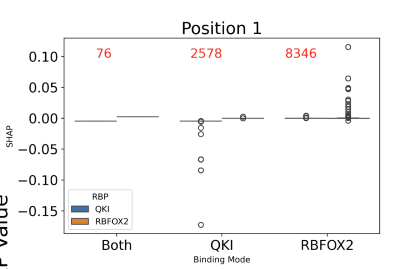

In [ ]:
K562_example = data_dict["K562"]

K562_example = K562_example.filter((pl.col("RBFOX2_5_left")==1) & (pl.col("QKI_5_left")==1))

K562_example.shape

K562_example.group_by(["target", "psi_hat"]).len()

K562_example.group_by(["RBFOX2_5_left_shap", "QKI_5_left_shap"]).len()



#### Hence, it seems to be the case that there isn't a data bug, other than the red text being doubled (it should be 38 and not 76). 

In [ ]:
unique_binding_patterns = K562_example[[column for column in K562_example.columns if column.endswith("_left") or column.endswith("_right")]].drop_duplicates().reset_index(drop=True)

unique_binding_patterns.head()

row1 = unique_binding_patterns.loc[0]
row2 = unique_binding_patterns.loc[1]

differing_columns = [col for col in unique_binding_patterns.columns if row1[col] != row2[col]]
differing_columns


## Helper Functions

In [ ]:
def get_global_SHAP_matrix(global_shap=None): 
    # Take all local SHAP columns and get the absolute value mean (Global SHAP)
    abs_mean_df = global_shap.select(
        [
            pl.col(col).abs().mean().alias(col) for col in global_shap.columns if col.endswith("_shap")
        ]
    )

    tmp_dict = {}
    for key, value in abs_mean_df.to_dict(as_series=False).items(): 
        rbp, position = get_rbp_and_position(key)
        
        if rbp not in tmp_dict: 
            tmp_dict[rbp] = {}

        tmp_dict[rbp][position] = value[0]

    return pd.DataFrame(tmp_dict).sort_index(axis=1).sort_index(axis=0)

In [ ]:
def get_total_binding_percent(df): 
    
    df = ((df.select(
        [col for col in df.columns if col.endswith("_left") or col.endswith("_right")]
    ).sum()) / (df.shape[0]))*100
    
    tmp_dict = {}
    for key, value in df.to_dict(as_series=False).items(): 
        rbp, position = get_rbp_and_position(key)
        
        if rbp not in tmp_dict: 
            tmp_dict[rbp] = {}

        tmp_dict[rbp][position] = value[0]

    return pd.DataFrame(tmp_dict).sort_index(axis=1).sort_index(axis=0)


In [ ]:
def get_positional_preference(df): 
    return df.copy(deep=True).apply(lambda x: (x / x.sum())*100)

In [ ]:
def partition_dataframe_by_PSI(df=None, column_name=None, psi_cutoffs=None): 

    return {
        f"PSI < {psi_cutoffs[0]}": 
            df.filter(pl.col(column_name) < psi_cutoffs[0]),
        f"PSI >= {psi_cutoffs[0]} & <= {psi_cutoffs[1]}": 
            df.filter((pl.col(column_name) >= psi_cutoffs[0]) & (pl.col(column_name) <= psi_cutoffs[1])),
        f"PSI > {psi_cutoffs[1]}":
            df.filter(pl.col(column_name) > psi_cutoffs[1])
    }


In [ ]:
def create_global_SHAP_vs_binding_plots(global_shap = None, binding_percentage=None, positional_preference=None, titles = None, cell_line = None, psi_info=None): 


    assert global_shap.columns.to_list() == binding_percentage.columns.to_list() == positional_preference.columns.to_list()
    assert global_shap.index.to_list() == binding_percentage.index.to_list() == positional_preference.index.to_list()

    for key in titles: 
        
        nrows=2
        
        fig, ax = plt.subplots(nrows, 1, figsize=(25,9), dpi=400)

        if psi_info==None: 
            title = cell_line
        else: 
            title = f"{cell_line}: {psi_info}"
        
        plt.suptitle(title, fontsize=40, x=0.5, y=1.0)

        if key=="Total Binding": 
            plotting_df = global_shap 
            title = "Global SHAP"
        elif key == "Positional Preference": 
            plotting_df = global_shap.apply(lambda x: (x / x.sum())*100, axis=0)
            title = "Per-RBP % Normalized Global SHAP"
            
        heatmap = sns.heatmap(plotting_df, xticklabels=True, yticklabels=True,ax=ax[0],cmap="Blues", cbar_kws={"pad": 0.01})
        heatmap.collections[0].colorbar.ax.tick_params(labelsize=18)
        ax[0].set_title(title, fontsize=24,)

        if key=="Total Binding": 
            plotting_df = binding_percentage
        elif key=="Positional Preference": 
            plotting_df = positional_preference

        heatmap = sns.heatmap(plotting_df, xticklabels=True, yticklabels=True,ax=ax[1],cmap="Blues", cbar_kws={"pad": 0.01})
        heatmap.collections[0].colorbar.ax.tick_params(labelsize=18)
        ax[1].set_title(titles[key], fontsize=24)
    
        plt.tight_layout()
        plt.show()
    

In [ ]:
def compare_cell_line_heatmaps(meta_plotting_df=None): 
    
    # Extract all dataframes from the nested dictionary
    dataframes = []
    for level1_key, level1_value in meta_plotting_df.items():
        for level2_key, df in level1_value.items():
            dataframes.append(df)
            
    # Check that all dataframes have the same columns and index names
    first_df = dataframes[0]
    for df in dataframes[1:]:
        if not (df.columns.equals(first_df.columns) and df.index.equals(first_df.index)):
            raise ValueError("All dataframes must have the same columns and index names")

    nrows = 2
    
    for key in meta_plotting_df: 

        fig, ax = plt.subplots(nrows, 1, figsize=(25,10), dpi=400)
        plt.suptitle(f"{key}", fontsize=40, x=0.5, y=1.0)

        sub_keys = sorted(list(meta_plotting_df[key].keys()))
        assert len(sub_keys)==nrows

        vmax = max([meta_plotting_df[key][sub_key].max().max() for sub_key in sub_keys])
        
        for index, sub_key in enumerate(sub_keys): 
            heatmap = sns.heatmap(meta_plotting_df[key][sub_key], xticklabels=True, yticklabels=True, ax=ax[index],cmap="Blues", vmax=vmax, cbar_kws={"pad": 0.01})
            heatmap.collections[0].colorbar.ax.tick_params(labelsize=18)
            ax[index].set_title(sub_key, fontsize=24,)
    
        plt.tight_layout()
        plt.show()

In [ ]:
def plot_partitioned_df_metrics(meta_plotting_df=None, cell_line=None, titles=None): 
    
    # Extract all dataframes from the nested dictionary
    dataframes = [dataframe for key in meta_plotting_df for dataframe in meta_plotting_df[key] if isinstance(dataframe, pd.DataFrame)]

    # Check that all dataframes have the same columns and index names
    first_df = dataframes[0]
    for df in dataframes[1:]:
        if not (df.columns.equals(first_df.columns) and df.index.equals(first_df.index)):
            raise ValueError("All dataframes must have the same columns and index names")

    nrows = {len(meta_plotting_df[key]) for key in meta_plotting_df}
    assert len(nrows)==1
    nrows = list(nrows)[0]
    
    for key in meta_plotting_df: 
        
        fig, ax = plt.subplots(nrows, 1, figsize=(25,10), dpi=400)
        plt.suptitle(f"{cell_line}: {key}", fontsize=40, x=0.5, y=1.0)

        vmax = max(
            [tmp_df.max().max() for tmp_df in meta_plotting_df[key]]
        )
        
        for i in range(nrows): 
            heatmap = sns.heatmap(meta_plotting_df[key][i], xticklabels=True, yticklabels=True, ax=ax[i],cmap="Blues", vmax=vmax, cbar_kws={"pad": 0.01})
            heatmap.collections[0].colorbar.ax.tick_params(labelsize=18)
            ax[i].set_title(titles[i], fontsize=24,)
    
        plt.tight_layout()
        plt.show()

In [ ]:
def retrieve_rbp_by_synonym(missing_rbp, missing_rbp_id, shap_rbp_columns, uniprot_mapping): 

    rbp_name = []
    
    mappings = pd.concat(
        [
            uniprot_mapping[uniprot_mapping["UniProtKB Gene Name ID"]==missing_rbp_id], 
            uniprot_mapping[uniprot_mapping["Gene name"]==missing_rbp], 
            uniprot_mapping[uniprot_mapping["Gene Synonym"]==missing_rbp]
        ]
    ).drop_duplicates()
        

    if len(mappings)==0: 
        return None 
                
    else: 
        rbp_synonyms = mappings["Gene name"].to_list() # + mappings["Gene Synonym"].to_list()

        for rbp in rbp_synonyms: 

            if rbp in shap_rbp_columns: 
                rbp_name.append(rbp)

    if len(rbp_name)==0: 
        return None 

    else: 
        rbp_name = list(set(rbp_name))
        assert len(rbp_name)==1
        return rbp_name[0]
        


In [ ]:
def retrieve_rbp_comparison_cols(df, rbp_ppi, uniprot_mapping): 

    interacting_columns = set()
    
    shap_rbp_columns = list({ column.split("_")[0].lower() for column in df.columns.to_list() if "_right" in column or "_left" in column })
        
    for index, row in rbp_ppi.iterrows(): 

        if row["Protein A"].lower() in shap_rbp_columns: 
            rbp_1 = row["Protein A"].lower()
        else: 
            rbp_1 = retrieve_rbp_by_synonym(row["Protein A"].lower(), row["UniProt accessions A"].lower(), shap_rbp_columns, uniprot_mapping) 
            
        if row["Protein B"].lower() in shap_rbp_columns: 
            rbp_2 = row["Protein B"].lower()
        else: 
            rbp_2 = retrieve_rbp_by_synonym(row["Protein B"].lower(), row["UniProt accessions B"].lower(), shap_rbp_columns, uniprot_mapping) 

        if rbp_1!=None and rbp_2!=None: 
            interacting_columns.add((rbp_1, rbp_2))

    return interacting_columns

In [ ]:
def plot_upstream_and_downstream_exon_duplication(tmp_df, cell_line=None): 

    if os.path.exists(f"../outputs/middle_exon_duplication/{cell_line}_inspect_duplication.csv"): 

        tmp_df = pd.read_csv(f"../outputs/middle_exon_duplication/{cell_line}_inspect_duplication.csv", index_col = 0)
        
        fig, axes = plt.subplots(1, 2, figsize=(12,3))
        
        # Histogram on the left subplot
        axes[0].hist(tmp_df['Counts'], bins=200, color='blue', edgecolor='black')
        axes[0].set_title('Histogram of Counts')
        axes[0].set_xlabel('Counts')
        axes[0].set_ylabel('Frequency')
        
        # Boxplot on the right subplot
        axes[1].boxplot(tmp_df['Counts'], vert=False)
        axes[1].set_title('Boxplot of Counts')
        axes[1].set_xlabel('Counts')
        
        plt.tight_layout()
        plt.show()
            
        return tmp_df

    else: 
        
        ense_counts = {}
        ense_counts["Counts"] = {}
    
        # Collect the unique values from the "ENSE" column
        unique_ense_values = tmp_df.select(pl.col("ENSE").unique()).to_series()
        
        # Iterate through each unique value in the "ENSE" column
        for ense_value in unique_ense_values:
            
            # Count occurrences of the unique value in the "ENSE_UP" column
            count = (tmp_df.filter(pl.col("ENSE_UP") == ense_value).height) + (tmp_df.filter(pl.col("ENSE_DN") == ense_value).height)
            # Store the count in the dictionary
            ense_counts["Counts"][ense_value] = count
    
        tmp_df = pd.DataFrame.from_dict(ense_counts)
    
        tmp_df = tmp_df.sort_values("Counts", ascending=False)
        tmp_df.to_csv(f"../outputs/middle_exon_duplication/{cell_line}_inspect_duplication.csv")

        return tmp_df 

In [ ]:
def feature_specific_chi_square_tests(tmp_df, cell_line, column):

    global psi_partition_thresholds
    partitions = partition_dataframe_by_PSI(df = tmp_df, column_name = "psi", psi_cutoffs = psi_partition_thresholds)

    results = {}
    for key in partitions: 
        results[key] = {}
        
        count_1 = partitions[key][column].sum()
        count_0 = partitions[key][column].shape[0] - count_1

        results[key]["Bound"] = count_1 
        results[key]["Unbound"] = count_0

    lists = pd.DataFrame.from_dict(results, orient="index").to_numpy().tolist()
    
    try: 
        result = scipy.stats.chi2_contingency(lists)
        return pd.DataFrame(
            [[
                column, 
                result.statistic, 
                result.pvalue
            ]], 
            columns=["Feature", "Statistic", "P-Val"]
        )
    except ValueError: 
        return pd.DataFrame(

            [[
                column, 
                None, 
                None
            ]], 
            columns = ["Feature", "Statistic", "P-Val"]
        ) 
    


In [ ]:
def plot_feature_chi_square_results(tmp_df, cell_line=None): 
    global splice_junction_position_renaming
    
    heatmap_df = {}
    for index, data in tmp_df.iterrows(): 
        rbp, position = get_rbp_and_position(data["Feature"])
        
        if rbp not in heatmap_df: 
            heatmap_df[rbp] = {}

        heatmap_df[rbp][position] = data["Statistic"]

    heatmap_df = pd.DataFrame.from_dict(heatmap_df, orient="columns").sort_index(axis=0).sort_index(axis=1)

    plt.figure(dpi=200,figsize=(30,10))
    
    _=plt.hist(heatmap_df.to_numpy().flatten(), bins=200)

    plt.title(f"{cell_line} CTRL ONLY: Per-Feature Chi-Square Statistic Histogram", pad=10, fontsize=20)
    plt.show()

    plt.figure(dpi=200, figsize=(50,10))

    mask = heatmap_df.isnull()
    
    cmap = sns.color_palette("Blues", as_cmap=True)
    cmap.set_bad("salmon")

    vmax = 10000
    sns.heatmap(heatmap_df, cmap=cmap, mask=mask, vmax=vmax)

    plt.title(f"{cell_line} CTRL ONLY: Per-Feature Chi-Square Statistic Heatmap (Capped at {vmax})", pad=40, fontsize=40)
    plt.show()
        
    return heatmap_df